# kmeans
Investigate the clusters of the clustering algorithm

> **Note:** This notebook needs a classification data set of many postcode areas (sample set, generated and analysed grids, clustering parameters; see the classification documentation and `pylovo-classify`). The stored outputs come from an earlier classification run with an older pylovo version; they were kept when the imports were updated and were not re-created.

In [ ]:
import warnings

import seaborn as sns

from pylovo.classification.clustering.clustering_algorithms import kmeans_clustering
from pylovo.classification.database_communication.database_communication import DatabaseCommunication
from pylovo.config_loader import LIST_OF_CLUSTERING_PARAMETERS, N_CLUSTERS_KMEANS, TUMPalette
from pylovo.plotting.classification import (
    plot_bar_distribution_of_clusters_per_regio_5,
    plot_percentage_of_clusters,
    plot_stacked_distribution_of_clusters_per_regio_5,
)

warnings.filterwarnings('ignore')

In [2]:
dc = DatabaseCommunication()
df_parameters_of_grids = dc.municipal_register_with_clustering_parameters_for_classification_version()

Database connection is constructed. 


In [3]:
df_parameters_of_grids, representative_networks = kmeans_clustering(df_parameters_of_grids=df_parameters_of_grids,
                                                                    list_of_clustering_parameters=LIST_OF_CLUSTERING_PARAMETERS,
                                                                    n_clusters=N_CLUSTERS_KMEANS)

plot percentage of clusters

In [ ]:
plot_percentage_of_clusters(df_plz_parameters=df_parameters_of_grids)

stacked bar plot of distribution of clusters over regio 5

In [ ]:
plot_stacked_distribution_of_clusters_per_regio_5(df_plz_parameters=df_parameters_of_grids)

bar plot of clusters in regio 5 classes side by side

In [ ]:
plot_bar_distribution_of_clusters_per_regio_5(df_plz_parameters=df_parameters_of_grids)

plot clusters over cluster parameters

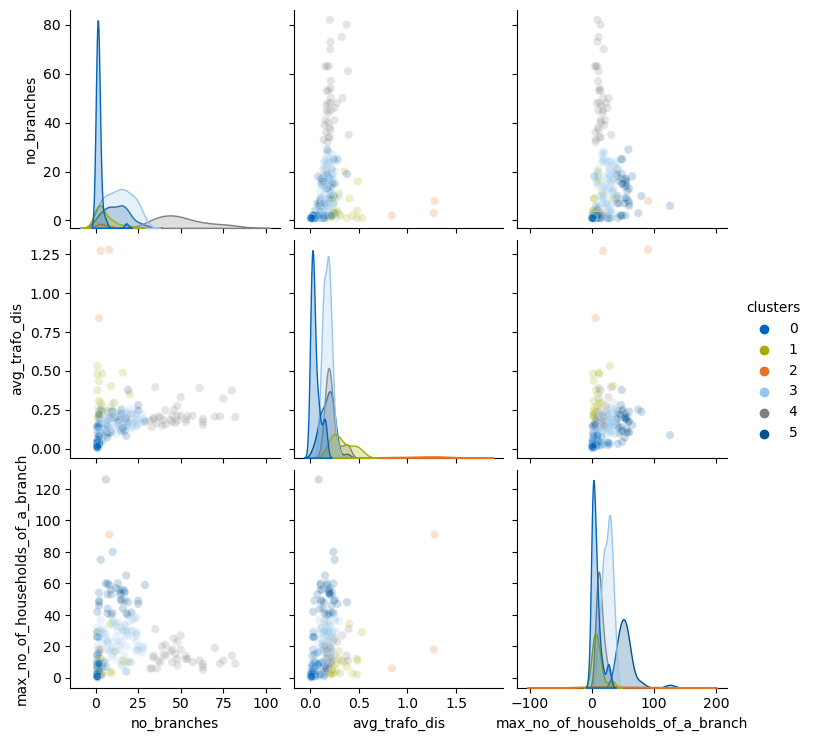

In [8]:
df_pairplot = df_parameters_of_grids[LIST_OF_CLUSTERING_PARAMETERS + ['clusters']]
sns.pairplot(data=df_pairplot, hue='clusters', palette=TUMPalette, kind='scatter', plot_kws={'alpha': 0.2})
# plt.savefig('pairplot.pdf', dpi=600, bbox_inches='tight')